In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc

# Import tất cả các model
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 1. Đọc dữ liệu xịn (K=30 + Graph)
df = pd.read_csv('eye_tracking_features_k30_graph.csv')

# 2. Tách X, y
X = df.drop(columns=['label', 'numeric_id'])
y = df['label']

# 3. Chia tập Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Chuẩn hóa (Bắt buộc cho nhiều thuật toán)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Hàm vẽ biểu đồ đánh giá "chuẩn cơm mẹ nấu"
def evaluate(model, X_input, y_true, name):
    y_pred = model.predict(X_input)
    # Lấy xác suất nếu có
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_input)[:, 1]
    else:
        y_prob = model.decision_function(X_input) if hasattr(model, "decision_function") else y_pred
    
    acc = accuracy_score(y_true, y_pred)
    print(f"🔹 {name} Accuracy: {acc*100:.2f}%")
    print("-" * 30)
    print(classification_report(y_true, y_pred, target_names=['Bình thường', 'Bệnh']))
    
    plt.figure(figsize=(10, 4))
    
    # Confusion Matrix
    plt.subplot(1, 2, 1)
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix ({name})')
    
    # ROC Curve
    plt.subplot(1, 2, 2)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color='orange', label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.legend()
    plt.title(f'ROC Curve ({name})')
    
    plt.tight_layout()
    plt.show()

print("✅ Đã chuẩn bị xong dữ liệu và hàm đánh giá!")

✅ Đã chuẩn bị xong dữ liệu và hàm đánh giá!


🔹 Random Forest Accuracy: 75.00%
------------------------------
              precision    recall  f1-score   support

 Bình thường       0.79      0.69      0.73        16
        Bệnh       0.72      0.81      0.76        16

    accuracy                           0.75        32
   macro avg       0.75      0.75      0.75        32
weighted avg       0.75      0.75      0.75        32



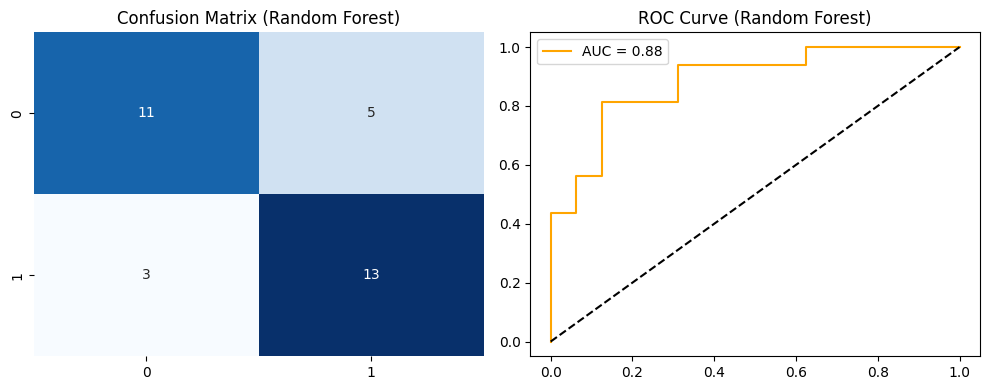

🔹 Extra Trees Accuracy: 84.38%
------------------------------
              precision    recall  f1-score   support

 Bình thường       1.00      0.69      0.81        16
        Bệnh       0.76      1.00      0.86        16

    accuracy                           0.84        32
   macro avg       0.88      0.84      0.84        32
weighted avg       0.88      0.84      0.84        32



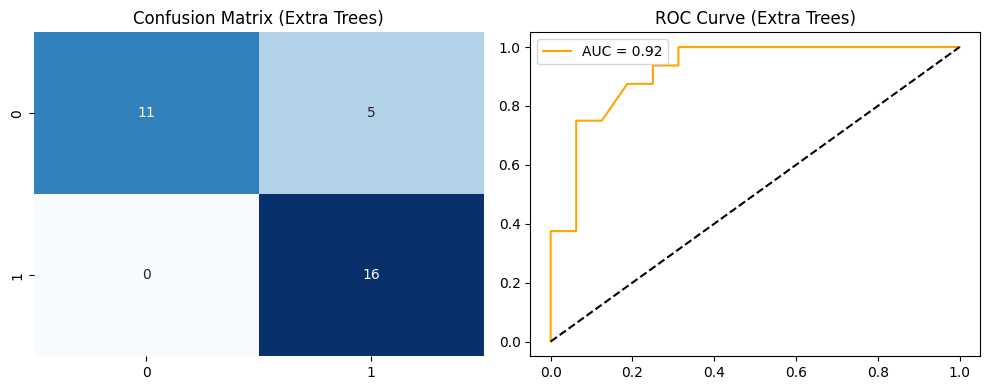

🔹 XGBoost Accuracy: 75.00%
------------------------------
              precision    recall  f1-score   support

 Bình thường       0.79      0.69      0.73        16
        Bệnh       0.72      0.81      0.76        16

    accuracy                           0.75        32
   macro avg       0.75      0.75      0.75        32
weighted avg       0.75      0.75      0.75        32



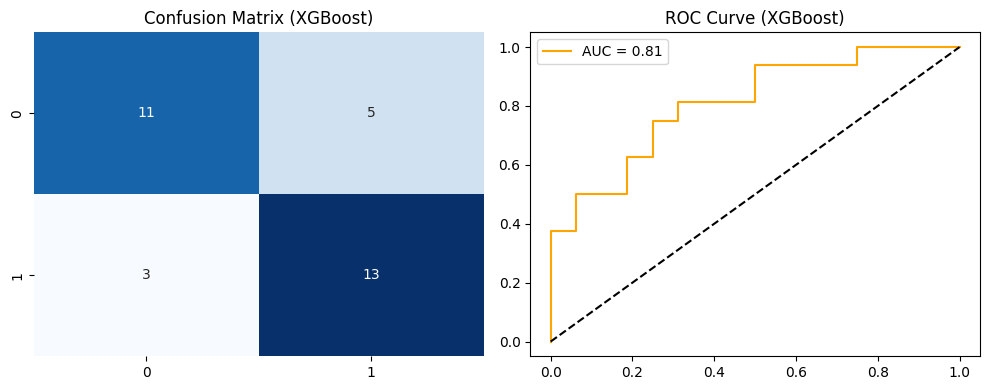

🔹 LightGBM Accuracy: 71.88%
------------------------------
              precision    recall  f1-score   support

 Bình thường       0.82      0.56      0.67        16
        Bệnh       0.67      0.88      0.76        16

    accuracy                           0.72        32
   macro avg       0.74      0.72      0.71        32
weighted avg       0.74      0.72      0.71        32



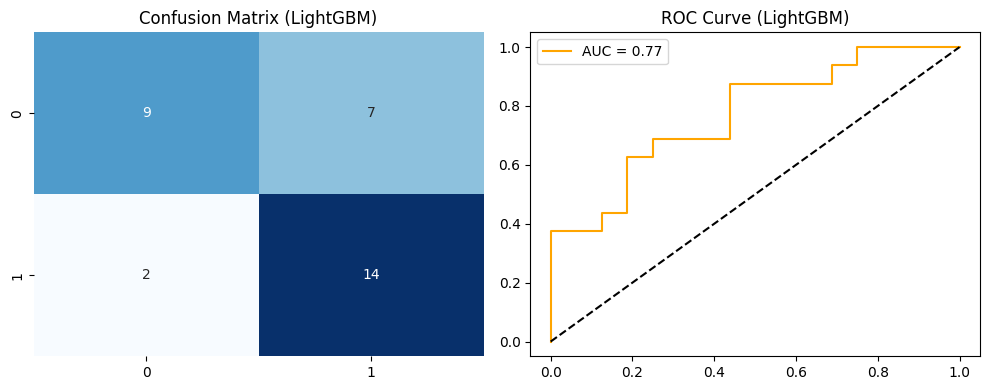

In [28]:
# --- RANDOM FOREST ---
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train) 
evaluate(rf, X_test, y_test, "Random Forest")

# --- EXTRA TREES (Cây ngẫu nhiên mở rộng) ---
et = ExtraTreesClassifier(n_estimators=200, random_state=42)
et.fit(X_train, y_train)
evaluate(et, X_test, y_test, "Extra Trees")

# --- XGBOOST ---
xgb = XGBClassifier(n_estimators=200, eval_metric='logloss', use_label_encoder=False, random_state=42)
xgb.fit(X_train, y_train)
evaluate(xgb, X_test, y_test, "XGBoost")

# --- LIGHTGBM ---
lgbm = LGBMClassifier(n_estimators=200, verbose=-1, random_state=42)
lgbm.fit(X_train, y_train)
evaluate(lgbm, X_test, y_test, "LightGBM")

🔹 Logistic Regression Accuracy: 78.12%
------------------------------
              precision    recall  f1-score   support

 Bình thường       0.85      0.69      0.76        16
        Bệnh       0.74      0.88      0.80        16

    accuracy                           0.78        32
   macro avg       0.79      0.78      0.78        32
weighted avg       0.79      0.78      0.78        32



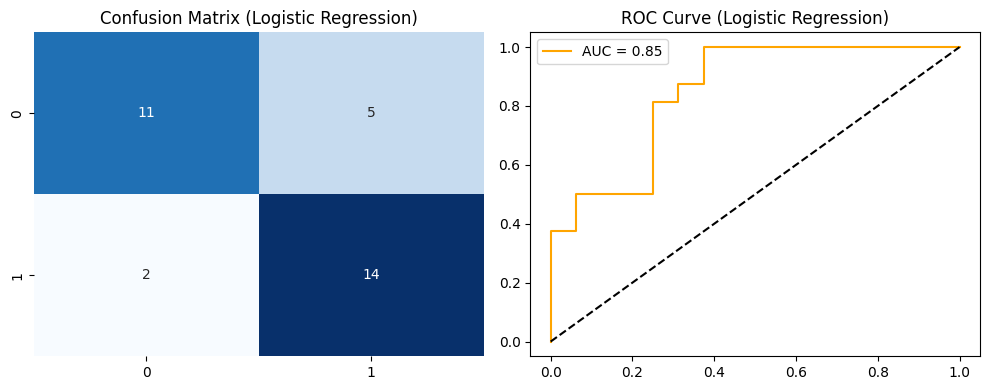

🔹 KNN (k=5) Accuracy: 53.12%
------------------------------
              precision    recall  f1-score   support

 Bình thường       1.00      0.06      0.12        16
        Bệnh       0.52      1.00      0.68        16

    accuracy                           0.53        32
   macro avg       0.76      0.53      0.40        32
weighted avg       0.76      0.53      0.40        32



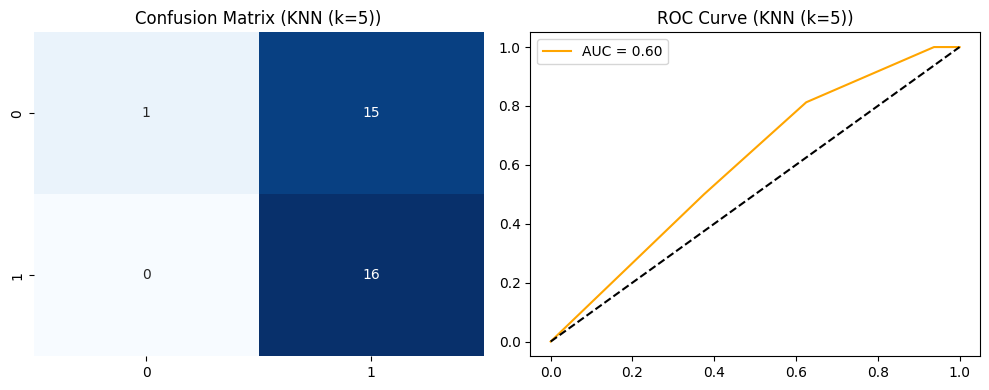

🔹 SVM (RBF) Accuracy: 71.88%
------------------------------
              precision    recall  f1-score   support

 Bình thường       0.71      0.75      0.73        16
        Bệnh       0.73      0.69      0.71        16

    accuracy                           0.72        32
   macro avg       0.72      0.72      0.72        32
weighted avg       0.72      0.72      0.72        32



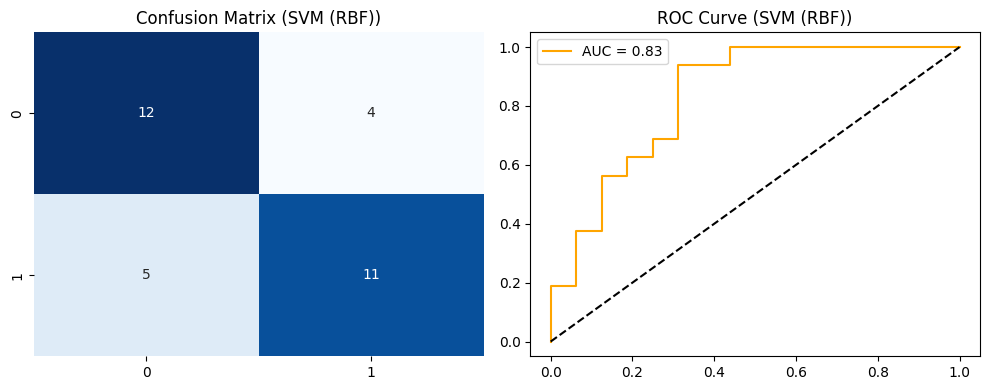

🔹 SVM (Linear) Accuracy: 75.00%
------------------------------
              precision    recall  f1-score   support

 Bình thường       0.79      0.69      0.73        16
        Bệnh       0.72      0.81      0.76        16

    accuracy                           0.75        32
   macro avg       0.75      0.75      0.75        32
weighted avg       0.75      0.75      0.75        32



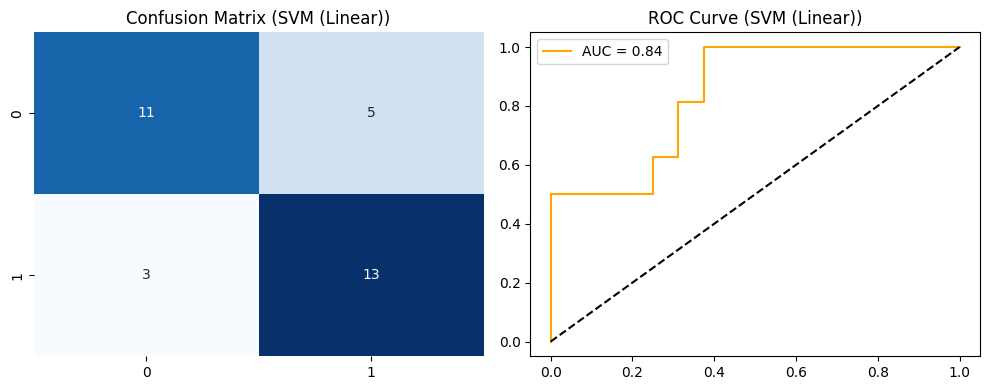

🔹 Neural Network (MLP) Accuracy: 71.88%
------------------------------
              precision    recall  f1-score   support

 Bình thường       0.77      0.62      0.69        16
        Bệnh       0.68      0.81      0.74        16

    accuracy                           0.72        32
   macro avg       0.73      0.72      0.72        32
weighted avg       0.73      0.72      0.72        32



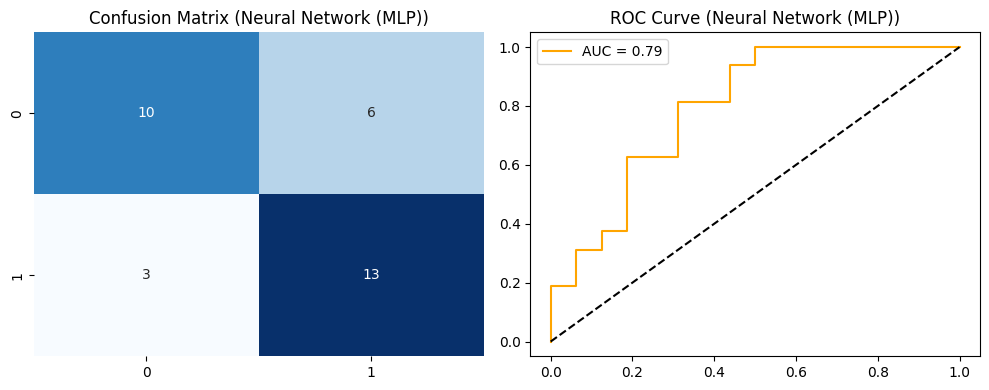

🔹 LDA Accuracy: 78.12%
------------------------------
              precision    recall  f1-score   support

 Bình thường       0.85      0.69      0.76        16
        Bệnh       0.74      0.88      0.80        16

    accuracy                           0.78        32
   macro avg       0.79      0.78      0.78        32
weighted avg       0.79      0.78      0.78        32



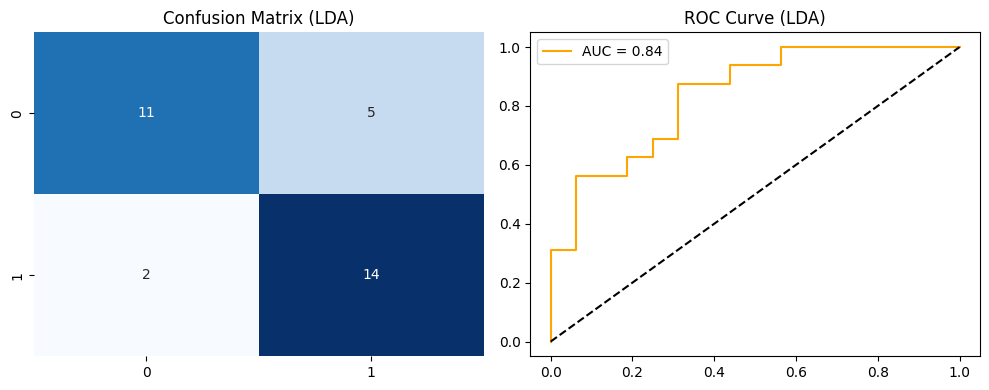

🔹 Gaussian Process Accuracy: 65.62%
------------------------------
              precision    recall  f1-score   support

 Bình thường       0.67      0.62      0.65        16
        Bệnh       0.65      0.69      0.67        16

    accuracy                           0.66        32
   macro avg       0.66      0.66      0.66        32
weighted avg       0.66      0.66      0.66        32



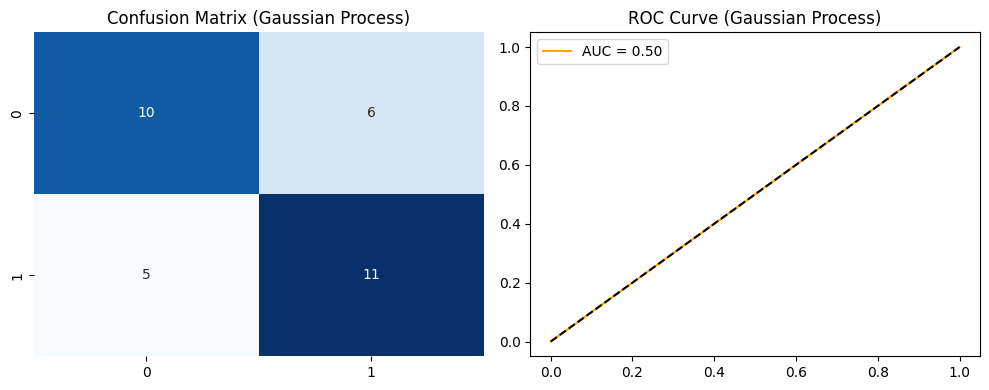

In [30]:
# --- LOGISTIC REGRESSION ---
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
evaluate(lr, X_test_scaled, y_test, "Logistic Regression")

# --- KNN (K-NEAREST NEIGHBORS) ---
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
evaluate(knn, X_test_scaled, y_test, "KNN (k=5)")

# --- SVM (RBF KERNEL - Mặc định) ---
svm_rbf = SVC(kernel='rbf', probability=True, random_state=42)
svm_rbf.fit(X_train_scaled, y_train)
evaluate(svm_rbf, X_test_scaled, y_test, "SVM (RBF)")

# --- SVM (LINEAR KERNEL - Tuyến tính) ---
svm_lin = SVC(kernel='linear', probability=True, random_state=42)
svm_lin.fit(X_train_scaled, y_train)
evaluate(svm_lin, X_test_scaled, y_test, "SVM (Linear)")

# --- MLP (NEURAL NETWORK) ---
mlp = MLPClassifier(max_iter=1000, random_state=42)
mlp.fit(X_train_scaled, y_train)
evaluate(mlp, X_test_scaled, y_test, "Neural Network (MLP)")

# --- LDA (LINEAR DISCRIMINANT ANALYSIS) ---
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train)
evaluate(lda, X_test_scaled, y_test, "LDA")

# --- GAUSSIAN PROCESS ---
gpc = GaussianProcessClassifier(1.0 * RBF(1.0), random_state=42)
gpc.fit(X_train_scaled, y_train)
evaluate(gpc, X_test_scaled, y_test, "Gaussian Process")

🔹 Gradient Boosting Accuracy: 84.38%
------------------------------
              precision    recall  f1-score   support

 Bình thường       1.00      0.69      0.81        16
        Bệnh       0.76      1.00      0.86        16

    accuracy                           0.84        32
   macro avg       0.88      0.84      0.84        32
weighted avg       0.88      0.84      0.84        32



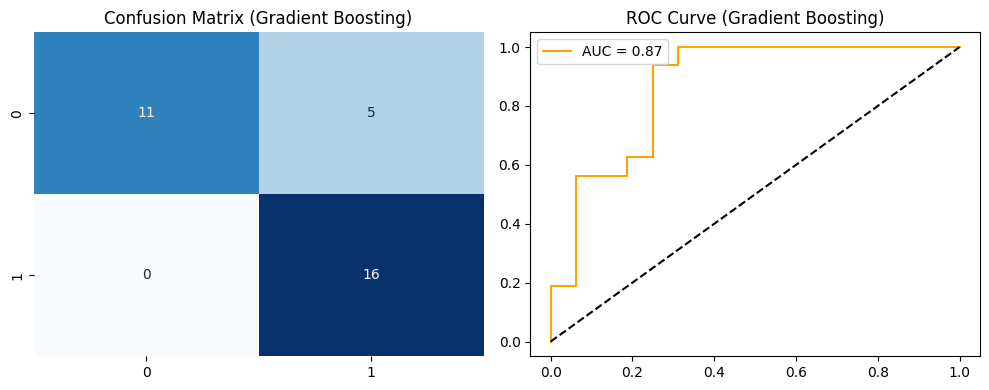

🔹 AdaBoost Accuracy: 75.00%
------------------------------
              precision    recall  f1-score   support

 Bình thường       0.79      0.69      0.73        16
        Bệnh       0.72      0.81      0.76        16

    accuracy                           0.75        32
   macro avg       0.75      0.75      0.75        32
weighted avg       0.75      0.75      0.75        32



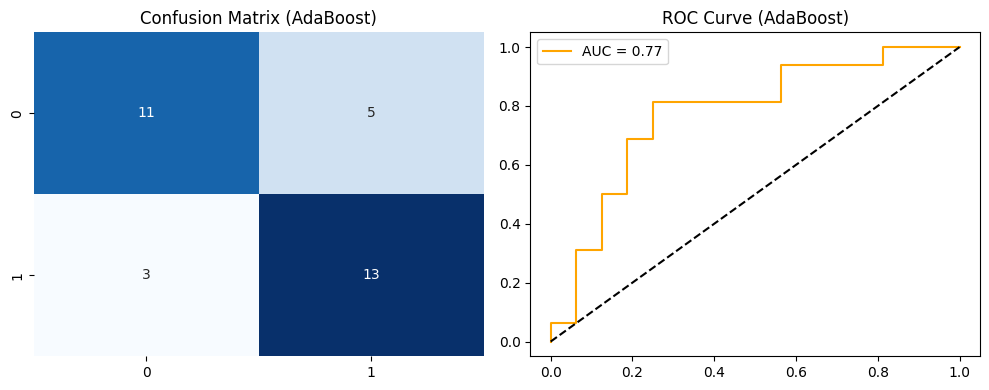

In [31]:
# 9. Gradient Boosting (CHAMPION 🏆)
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)
evaluate(gb, X_test, y_test, "Gradient Boosting")

# 10. AdaBoost
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)
evaluate(ada, X_test, y_test, "AdaBoost")

🔹 CatBoost Accuracy: 81.25%
------------------------------
              precision    recall  f1-score   support

 Bình thường       0.92      0.69      0.79        16
        Bệnh       0.75      0.94      0.83        16

    accuracy                           0.81        32
   macro avg       0.83      0.81      0.81        32
weighted avg       0.83      0.81      0.81        32



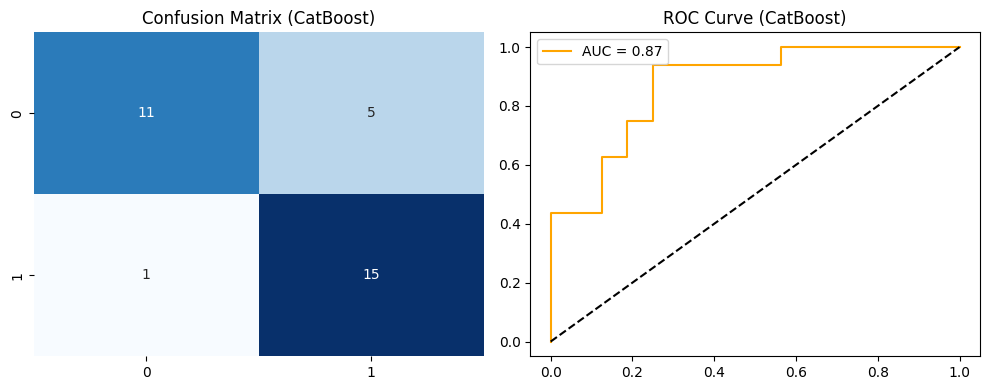

🔹 Voting Ensemble Accuracy: 81.25%
------------------------------
              precision    recall  f1-score   support

 Bình thường       1.00      0.62      0.77        16
        Bệnh       0.73      1.00      0.84        16

    accuracy                           0.81        32
   macro avg       0.86      0.81      0.81        32
weighted avg       0.86      0.81      0.81        32



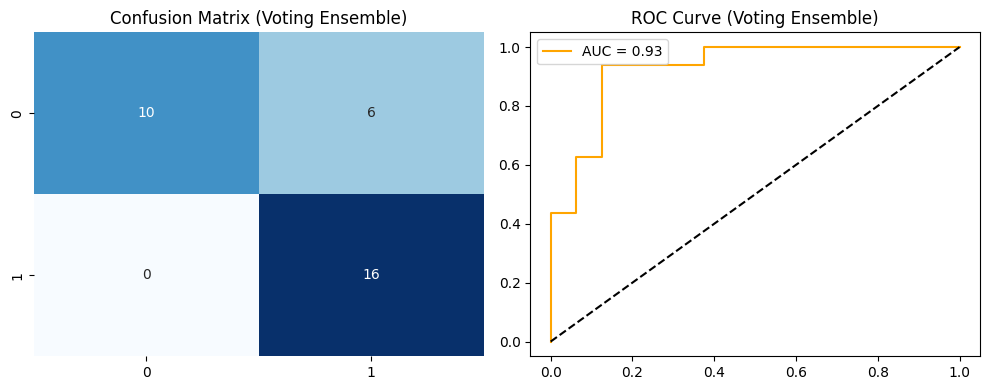

In [32]:
from sklearn.base import BaseEstimator, ClassifierMixin
from catboost import CatBoostClassifier

# --- CATBOOST (Wrapper để tránh lỗi Sklearn) ---
class CatBoostWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, iterations=200, verbose=0, random_state=42):
        self.iterations = iterations
        self.verbose = verbose
        self.random_state = random_state
        self.model = None
    def fit(self, X, y):
        self.model = CatBoostClassifier(iterations=self.iterations, verbose=self.verbose, 
                                        random_state=self.random_state, allow_writing_files=False)
        self.model.fit(X, y)
        self.classes_ = self.model.classes_ 
        return self
    def predict(self, X): return self.model.predict(X)
    def predict_proba(self, X): return self.model.predict_proba(X)

cat = CatBoostWrapper(iterations=200, verbose=0, random_state=42)
cat.fit(X_train, y_train) # CatBoost dùng X gốc ok
evaluate(cat, X_test, y_test, "CatBoost")


# --- VOTING ENSEMBLE ---
# Kết hợp: GB (Gốc) + ExtraTrees (Gốc) + SVM (Linear)
# Lưu ý: Để Voting chạy trơn tru, ta nên dùng X_scaled cho toàn bộ để SVM không bị lệch
clf1 = GradientBoostingClassifier(n_estimators=200, random_state=42)
clf2 = ExtraTreesClassifier(n_estimators=200, random_state=42)
clf3 = SVC(kernel='linear', probability=True, random_state=42)

voting = VotingClassifier(estimators=[
    ('gb', clf1), ('et', clf2), ('svm', clf3)], voting='soft')

voting.fit(X_train_scaled, y_train)
evaluate(voting, X_test_scaled, y_test, "Voting Ensemble")

Đang tổng hợp kết quả...


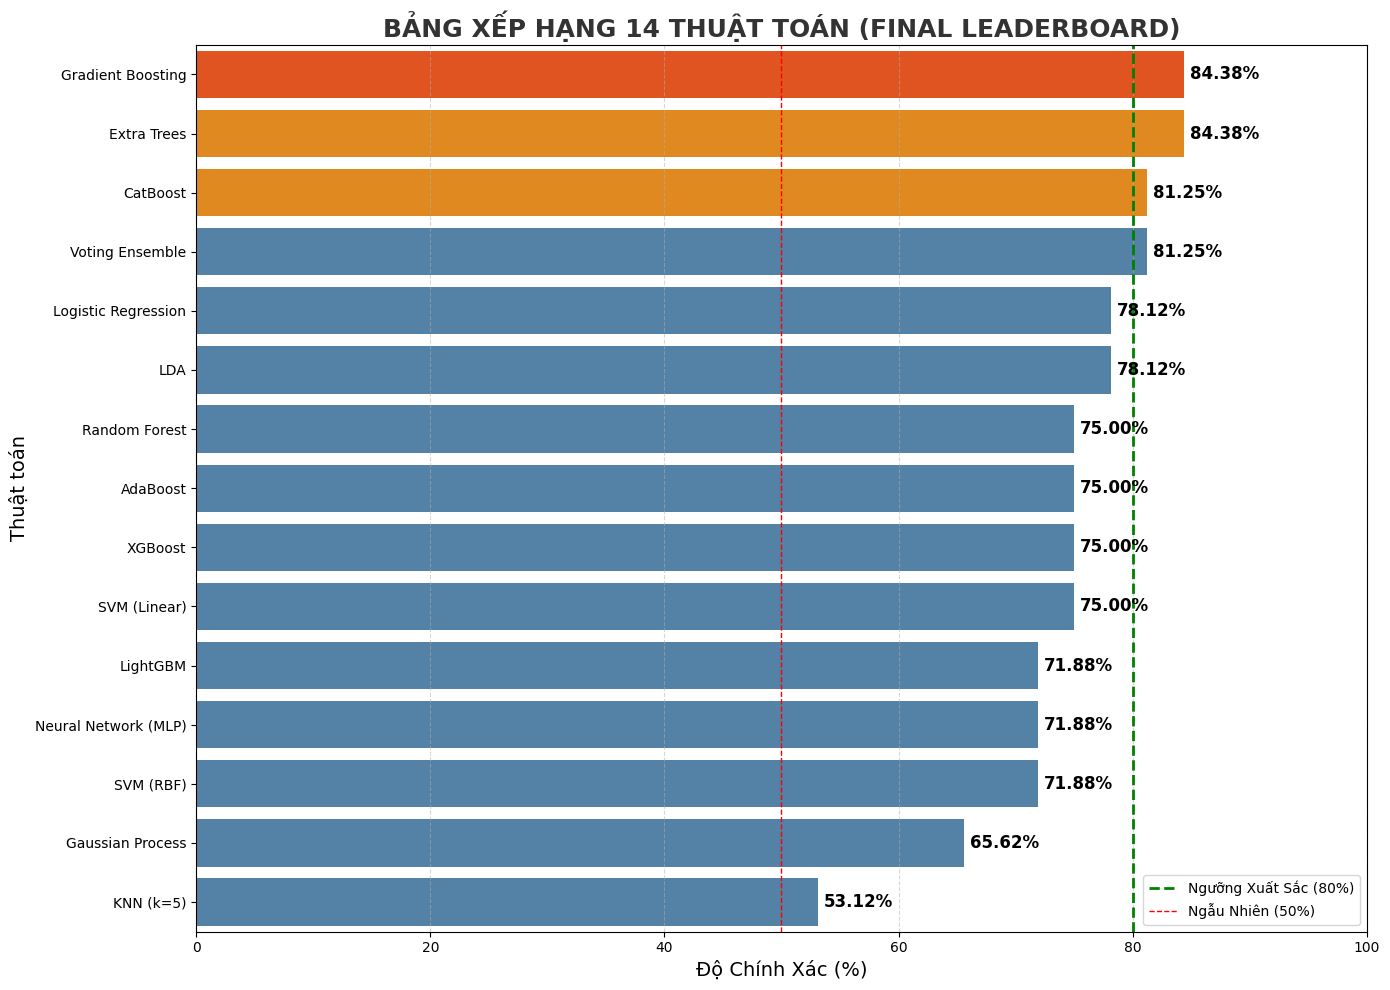


XẾP HẠNG | MÔ HÌNH                   | ĐỘ CHÍNH XÁC
1     | Gradient Boosting         | 84.38%
2     | Extra Trees               | 84.38%
3     | CatBoost                  | 81.25%
4     | Voting Ensemble           | 81.25%
5     | Logistic Regression       | 78.12%
6     | LDA                       | 78.12%
7     | Random Forest             | 75.00%
8     | AdaBoost                  | 75.00%
9     | XGBoost                   | 75.00%
10    | SVM (Linear)              | 75.00%
11    | LightGBM                  | 71.88%
12    | Neural Network (MLP)      | 71.88%
13    | SVM (RBF)                 | 71.88%
14    | Gaussian Process          | 65.62%
15    | KNN (k=5)                 | 53.12%

🏆 MÔ HÌNH VÔ ĐỊCH: Gradient Boosting


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

# --- 1. TỔNG HỢP CÁC MODEL ĐÃ TRAIN ---
# (Đảm bảo bạn đã chạy các cell train model ở trên rồi nhé)

# Danh sách chứa: (Tên hiển thị, Biến Model, Loại dữ liệu cần dùng)
# 'original': Dùng X_test (cho cây)
# 'scaled': Dùng X_test_scaled (cho SVM, KNN...)

competitors = [
    # Nhóm Cây (Dữ liệu Gốc)
    ('Gradient Boosting', gb, 'original'),
    ('Random Forest', rf, 'original'),
    ('Extra Trees', et, 'original'),
    ('AdaBoost', ada, 'original'),
    ('XGBoost', xgb, 'original'),
    ('LightGBM', lgbm, 'original'),
    ('CatBoost', cat, 'original'), # Biến 'cat' từ cell CatBoost
    
    # Nhóm Khoảng cách/Tuyến tính (Dữ liệu Scaled)
    ('Logistic Regression', lr, 'scaled'),
    ('KNN (k=5)', knn, 'scaled'),
    ('SVM (RBF)', svm_rbf, 'scaled'),
    ('SVM (Linear)', svm_lin, 'scaled'),
    ('Neural Network (MLP)', mlp, 'scaled'),
    ('LDA', lda, 'scaled'),
    ('Gaussian Process', gpc, 'scaled'),
    
    # Nhóm Hỗn hợp (Voting dùng Scaled cho an toàn)
    ('Voting Ensemble', voting, 'scaled')
]

# --- 2. CHẠY VÒNG LẶP ĐÁNH GIÁ ---
results = []

print("Đang tổng hợp kết quả...")

for name, model, data_type in competitors:
    try:
        # Chọn dữ liệu test phù hợp
        if data_type == 'scaled':
            X_input = X_test_scaled
        else:
            X_input = X_test
            
        # Dự đoán và tính điểm
        y_pred = model.predict(X_input)
        acc = accuracy_score(y_test, y_pred)
        
        results.append({'Model': name, 'Accuracy': acc * 100})
    except Exception as e:
        print(f"Lỗi tại model {name}: {e}")
        results.append({'Model': name, 'Accuracy': 0})

# --- 3. TẠO DATAFRAME VÀ SẮP XẾP ---
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

# --- 4. VẼ BIỂU ĐỒ SO SÁNH (VISUALIZATION) ---
plt.figure(figsize=(14, 10))

# Tạo bảng màu: Top 1 Đỏ, Top 2-3 Cam, còn lại Xanh
colors = []
for i in range(len(df_results)):
    if i == 0:
        colors.append('#FF4500') # Đỏ cam (Quán quân)
    elif i < 3:
        colors.append('#FF8C00') # Cam đậm (Á quân)
    else:
        colors.append('#4682B4') # Xanh thép (Các model còn lại)

ax = sns.barplot(x='Accuracy', y='Model', data=df_results, palette=colors)

# Thêm số liệu lên từng cột
for i, v in enumerate(df_results['Accuracy']):
    ax.text(v + 0.5, i, f'{v:.2f}%', va='center', fontweight='bold', fontsize=12)

# Trang trí
plt.title('BẢNG XẾP HẠNG 14 THUẬT TOÁN (FINAL LEADERBOARD)', fontsize=18, fontweight='bold', color='#333333')
plt.xlabel('Độ Chính Xác (%)', fontsize=14)
plt.ylabel('Thuật toán', fontsize=14)
plt.xlim(0, 100) # Thang đo 100%
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Vẽ đường mốc tham chiếu
plt.axvline(x=80, color='green', linestyle='--', linewidth=2, label='Ngưỡng Xuất Sắc (80%)')
plt.axvline(x=50, color='red', linestyle='--', linewidth=1, label='Ngẫu Nhiên (50%)')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

# --- 5. IN BẢNG RA MÀN HÌNH ---
print("\n" + "="*40)
print(f"{'XẾP HẠNG':<5} | {'MÔ HÌNH':<25} | {'ĐỘ CHÍNH XÁC'}")
print("="*40)
for i, row in df_results.iterrows():
    print(f"{i+1:<5} | {row['Model']:<25} | {row['Accuracy']:.2f}%")
print("="*40)

print(f"\n🏆 MÔ HÌNH VÔ ĐỊCH: {df_results.iloc[0]['Model']}")